# Figures: study area and the spatial-block split

Two figures the write-up needs and does not have. Both are built from patch
geometry alone -- no model, no GPU, no basemap package.

**Figure 1, study area.** Where the two sites are, and what the patch
coverage looks like at each. Near-universal in remote-sensing work, and
conspicuous by its absence.

**Figure 2, the split.** Patch centroids coloured by training, validation
and dropped-as-buffer, with the 1024 m block grid drawn over them. The
claim that the buffer discards 53% of the data is far easier to see than
to read, and the figure also shows *why* the discarded patches sit where
they do.

The split is recomputed here with the same logic and the same seed as the
training notebooks, and asserts 534/255 before plotting, so the figure
shows the real split rather than an illustration of one.

## Setup

In [1]:
import json, math, random
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TUK_LIDAR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
TUK_S1 = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
CB_LIDAR = WORKING_REPO / 'input_data' / 'lidar_patches_cambridge_extracted' / 'lidar_patches_cambridge'
CB_S1 = WORKING_REPO / 'input_data' / 's1_patches_cambridge_pcrtc'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BLOCK_SIZE_M, BUFFER_M, VAL_FRACTION, SEED = 1024.0, 150.0, 0.15, 42

SITES = {
    'Tuktoyaktuk': dict(lidar=TUK_LIDAR, s1=TUK_S1, survey='2024-04-16', colour='#1D4E63'),
    'Cambridge Bay': dict(lidar=CB_LIDAR, s1=CB_S1, survey='2024-04-18', colour='#A8561A'),
}

def patch_bounds(lidar_dir, limit=None):
    """Native bounds plus WGS84 bounds for every LiDAR patch."""
    paths = sorted(lidar_dir.glob('lidar_patch_*.tif'))
    if limit:
        paths = paths[:limit]
    native, wgs = {}, {}
    crs = None
    for p in paths:
        pid = p.stem.split('_')[-1]
        with rasterio.open(p) as src:
            native[pid] = src.bounds
            crs = src.crs
            wgs[pid] = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
    return native, wgs, crs

data = {}
for name, cfg in SITES.items():
    if not cfg['lidar'].exists():
        print(f'{name}: LiDAR directory not found, skipping')
        continue
    nat, wgs, crs = patch_bounds(cfg['lidar'])
    s1_ids = {p.name.split('_')[-1] for p in cfg['s1'].glob('s1_patch_*') if p.is_dir()} if cfg['s1'].exists() else set()
    data[name] = dict(native=nat, wgs=wgs, crs=crs, paired=sorted(set(nat) & s1_ids), **cfg)
    lons = [b[0] for b in wgs.values()]; lats = [b[1] for b in wgs.values()]
    print(f'{name}: {len(nat)} LiDAR patches, {len(data[name]["paired"])} paired with S1, '
          f'{crs}, centre {np.mean(lats):.2f}N {np.mean(lons):.2f}E')

Tuktoyaktuk: 1676 LiDAR patches, 1676 paired with S1, EPSG:32608, centre 69.77N -133.32E
Cambridge Bay: 2112 LiDAR patches, 2101 paired with S1, EPSG:32613, centre 68.99N -105.83E


## Figure 1 — study area

Three panels: an Arctic overview locating both sites, then the patch
footprints at each. Longitude is scaled by cos(latitude) so shapes are not
distorted at these latitudes.

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/fig_study_area.png


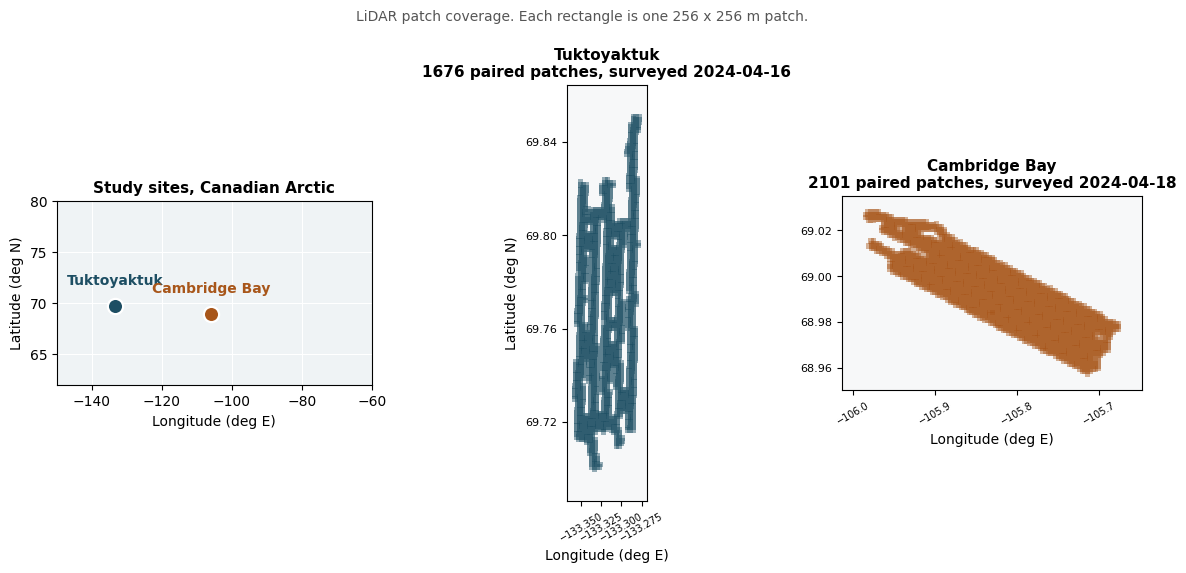

In [4]:
fig = plt.figure(figsize=(14, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1, 1], wspace=0.28)

# --- overview ---
ax = fig.add_subplot(gs[0])
ax.set_facecolor('#EFF3F5')
for lon in range(-160, -41, 20):
    ax.axvline(lon, color='white', lw=0.8, zorder=0)
for lat in range(60, 86, 5):
    ax.axhline(lat, color='white', lw=0.8, zorder=0)

for name, d in data.items():
    lon = np.mean([(b[0] + b[2]) / 2 for b in d['wgs'].values()])
    lat = np.mean([(b[1] + b[3]) / 2 for b in d['wgs'].values()])
    ax.plot(lon, lat, 'o', ms=11, color=d['colour'], mec='white', mew=1.6, zorder=3)
    ax.annotate(name, (lon, lat), textcoords='offset points', xytext=(0, 15),
                ha='center', fontsize=10, fontweight='bold', color=d['colour'])
ax.set_xlim(-150, -60); ax.set_ylim(62, 80)
ax.set_aspect(1 / math.cos(math.radians(70)))
ax.set_xlabel('Longitude (deg E)'); ax.set_ylabel('Latitude (deg N)')
ax.set_title('Study sites, Canadian Arctic', fontweight='bold', fontsize=11)

# --- per-site footprints ---
for i, (name, d) in enumerate(data.items()):
    ax = fig.add_subplot(gs[i + 1])
    ax.set_facecolor('#F7F8F9')
    for b in d['wgs'].values():
        ax.add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                               facecolor=d['colour'], edgecolor='none', alpha=0.45))
    lons = [v for b in d['wgs'].values() for v in (b[0], b[2])]
    lats = [v for b in d['wgs'].values() for v in (b[1], b[3])]
    mx, my = (max(lons) - min(lons)) * 0.08, (max(lats) - min(lats)) * 0.08
    ax.set_xlim(min(lons) - mx, max(lons) + mx)
    ax.set_ylim(min(lats) - my, max(lats) + my)
    ax.set_aspect(1 / math.cos(math.radians(np.mean(lats))))
    ax.set_xlabel('Longitude (deg E)')
    if i == 0:
        ax.set_ylabel('Latitude (deg N)')
    ax.set_title(f"{name}\n{len(d['paired'])} paired patches, surveyed {d['survey']}",
                 fontweight='bold', fontsize=11)
    ax.tick_params(labelsize=8)
    ax.ticklabel_format(axis='both', style='plain', useOffset=False)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.tick_params(axis='x', labelrotation=30, labelsize=7)


plt.suptitle('LiDAR patch coverage. Each rectangle is one 256 x 256 m patch.',
             y=1.02, fontsize=10, color='#555')
out = OUTPUT_DIR / 'fig_study_area.png'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('Saved:', out)
plt.show()

## Figure 2 — the spatial-block split

Recomputes the split with the same logic and seed as the training
notebooks, and asserts 534/255 before drawing, so this is the actual split
rather than a schematic.

train=534  val=255  dropped=887  (53% of 1676)
Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/fig_spatial_block_split.png

Grey bands along the block boundaries are the buffer. Their width is
150 m either side of each line, which is why half of each
1024 m block is discarded: (1024-300)^2 / 1024^2 = 0.50.


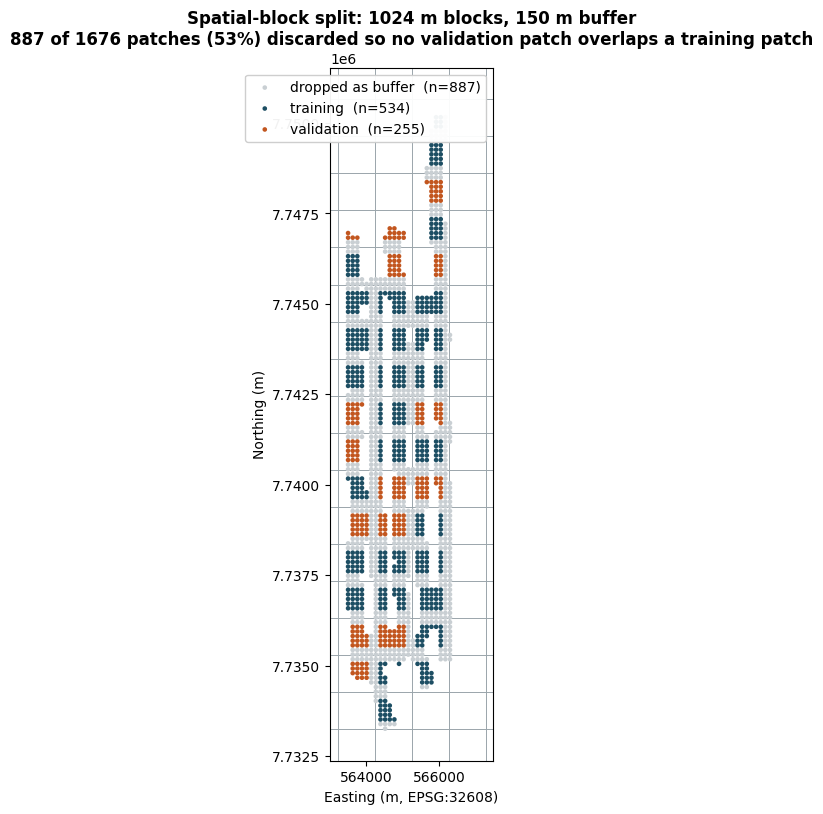

In [3]:
d = data['Tuktoyaktuk']
paired, native = d['paired'], d['native']

centroids = {p: ((native[p].left + native[p].right) / 2,
                 (native[p].bottom + native[p].top) / 2) for p in paired}

def block_and_dist(cx, cy, bs):
    bx, by = int(cx // bs), int(cy // bs)
    return (bx, by), min(min(cx - bx * bs, (bx + 1) * bs - cx),
                         min(cy - by * bs, (by + 1) * bs - cy))

blocks, dropped = {}, []
for p, (cx, cy) in centroids.items():
    bid, dist = block_and_dist(cx, cy, BLOCK_SIZE_M)
    (dropped.append(p) if dist < BUFFER_M else blocks.setdefault(bid, []).append(p))

ids = list(blocks.keys())
random.Random(SEED).shuffle(ids)
target = int(len(paired) * VAL_FRACTION)
val, train, n = [], [], 0
for bid in ids:
    if n < target:
        val.extend(blocks[bid]); n += len(blocks[bid])
    else:
        train.extend(blocks[bid])

print(f'train={len(train)}  val={len(val)}  dropped={len(dropped)}  '
      f'({len(dropped) / len(paired):.0%} of {len(paired)})')
assert (len(train), len(val)) == (534, 255), 'Split does not match the training notebooks.'

fig, ax = plt.subplots(figsize=(9.5, 9))
xs = [c[0] for c in centroids.values()]; ys = [c[1] for c in centroids.values()]

b0x, b1x = math.floor(min(xs) / BLOCK_SIZE_M), math.ceil(max(xs) / BLOCK_SIZE_M)
b0y, b1y = math.floor(min(ys) / BLOCK_SIZE_M), math.ceil(max(ys) / BLOCK_SIZE_M)
for bx in range(b0x, b1x + 1):
    ax.axvline(bx * BLOCK_SIZE_M, color='#9AA5AB', lw=0.7, zorder=1)
for by in range(b0y, b1y + 1):
    ax.axhline(by * BLOCK_SIZE_M, color='#9AA5AB', lw=0.7, zorder=1)

STYLE = [(dropped, '#C9CFD3', 'dropped as buffer'),
         (train,   '#1D4E63', 'training'),
         (val,     '#C2561F', 'validation')]
for group, colour, label in STYLE:
    ax.scatter([centroids[p][0] for p in group], [centroids[p][1] for p in group],
               s=11, c=colour, label=f'{label}  (n={len(group)})',
               edgecolors='none', zorder=2 if label.startswith('dropped') else 3)

ax.set_aspect('equal')
ax.set_xlabel(f'Easting (m, {d["crs"]})'); ax.set_ylabel('Northing (m)')
ax.set_title(f'Spatial-block split: {BLOCK_SIZE_M:.0f} m blocks, {BUFFER_M:.0f} m buffer\n'
             f'{len(dropped)} of {len(paired)} patches ({len(dropped)/len(paired):.0%}) '
             f'discarded so no validation patch overlaps a training patch',
             fontweight='bold', fontsize=12)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
ax.grid(False)

out = OUTPUT_DIR / 'fig_spatial_block_split.png'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('Saved:', out)
print('\nGrey bands along the block boundaries are the buffer. Their width is')
print(f'{BUFFER_M:.0f} m either side of each line, which is why half of each')
print(f'{BLOCK_SIZE_M:.0f} m block is discarded: (1024-300)^2 / 1024^2 = 0.50.')
plt.show()